# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

## AlpesPlanck

**Integrantes:**
- Daniel Esteban Pardo Pardo
- Samuel Andrés Molina Luna

**Curso:** ISIS2611 - Aprendizaje de Máquina
**Fecha:** 14 de septiembre

# 1. Contexto

En el Laboratorio 1 se construyó para AlpesPlanck un primer modelo de regresión lineal para
estimar la temperatura máxima del día siguiente en la estación de Jena, Alemania, identificando
las variables más influyentes y reflexionando sobre posibles fuentes de sesgo.

En este laboratorio se busca fortalecer ese primer acercamiento evaluando otros enfoques de
modelado (regresión polinomial y regularizada), analizando el efecto de la complejidad sobre la
capacidad de generalización, y cuantificando la incertidumbre del modelo mediante intervalos de
confianza obtenidos por remuestreo (bootstrapping).

Se reutiliza el mismo conjunto de datos del Laboratorio 1, aplicando el mismo proceso de
limpieza y preparación ya validado (Modelo 2 / `df_m2`), de forma que el énfasis de este
laboratorio esté en el modelado, la validación y el análisis del desempeño predictivo.

# 2. Carga de datos y librerías

### Librerías a usar en el transcurso del laboratorio
Librerías de Python para el procesamiento, modelado y análisis de datos:

- Pandas
- Scikit-Learn
- Matplotlib, Seaborn
- NumPy

In [1]:
# Importación de las librerías a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

from sklearn import set_config
set_config(display="diagram")

np.random.seed(42)

### Cargar datos a DataFrames

In [2]:
# Dataset de entrenamiento (mismo del Laboratorio 1)
data = pd.read_csv('data/Datos Lab 1.csv')
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [3]:
# Dataset de prueba / producción (sin etiqueta), igual que en el Laboratorio 1
data_test = pd.read_csv('data/Datos Test Lab 1.csv')
data_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


# 3. Reconstrucción del conjunto de datos limpio (Modelo 2 del Laboratorio 1)

Tal como indica el enunciado, este laboratorio no repite la exploración ni el procesamiento de
datos ya realizado en el Laboratorio 1 — se reutiliza directamente la versión resultante de esa
limpieza y preparación (el `df_m2` del Laboratorio 1, correspondiente al modelo optimizado).

A continuación se reproducen, de forma resumida y sin volver a justificar cada decisión, los
mismos pasos de limpieza aplicados en el Laboratorio 1, para partir exactamente del mismo punto.

**3.1 Unicidad — eliminación de duplicados**

In [4]:
df_base = data.copy()
len_inicial = len(df_base)

# Eliminar duplicados exactos
df_base = df_base.drop_duplicates()
duplicados_exactos = len_inicial - len(df_base)

# Manejar fechas duplicadas: conservar la que tenga menos valores NaN
df_base['num_nans'] = df_base.isnull().sum(axis=1)
df_base = df_base.sort_values(by=['fecha', 'num_nans'])
df_base = df_base.drop_duplicates(subset=['fecha'], keep='first')
df_base = df_base.drop(columns=['num_nans'])

print(f"Registros tras depuración de duplicados: {len(df_base)}")

Registros tras depuración de duplicados: 2487


**3.2 Completitud — eliminación de registros sin variable objetivo**

In [5]:
df_base = df_base.dropna(subset=['temp_max_manana'])
print(f"Registros con temp_max_manana no nula: {len(df_base)}")

Registros con temp_max_manana no nula: 2394


**3.3 Validez — tratamiento de valores anómalos y centinela**

In [6]:
# Presión atmosférica (Dominio real ~940 a 1040 mbar)
cols_presion = [c for c in df_base.columns if 'presion' in c and 'desv' not in c and 'std' not in c]
for col in cols_presion:
    df_base.loc[(df_base[col] < 940) | (df_base[col] > 1040), col] = np.nan

# Humedad relativa (Clipping al 100% y depuración de 0s artificiales)
cols_humedad = [c for c in df_base.columns if 'humedad' in c]
for col in cols_humedad:
    df_base.loc[df_base[col] > 100, col] = 100.0
    df_base.loc[df_base[col] <= 0.05, col] = np.nan

# Viento, ráfagas y desviaciones estándar
cols_viento_rafaga = [c for c in df_base.columns if 'viento' in c or 'rafaga' in c]
for col in cols_viento_rafaga:
    if 'desv' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan
    if 'media' in col or 'min' in col or 'max' in col:
        df_base.loc[df_base[col] < 0, col] = np.nan

df_base.loc[df_base['viento_desv'] > 100, 'viento_desv'] = np.nan
df_base.loc[df_base['viento_norte'] < -100, 'viento_norte'] = np.nan

# Registros del día (máximo 144 mediciones por día)
if 'registros_del_dia' in df_base.columns:
    df_base.loc[df_base['registros_del_dia'] > 144, 'registros_del_dia'] = 144

# Depuración de la variable objetivo
df_base.loc[df_base['temp_max_manana'] > 50.0, 'temp_max_manana'] = np.nan
df_base = df_base.dropna(subset=['temp_max_manana'])

print(f"Registros finales tras depuración de valores anómalos: {len(df_base)}")

Registros finales tras depuración de valores anómalos: 2392


**3.4 Consistencia — normalización de variables categóricas**

In [7]:
# Eliminar la columna 'fecha' por redundancia con dia, mes y anio
if 'fecha' in df_base.columns:
    df_base = df_base.drop(columns=['fecha'])

cat_cols_raw = df_base.select_dtypes(include=['object']).columns

for col in cat_cols_raw:
    mask_nulls = df_base[col].isnull()
    df_base[col] = df_base[col].astype(str).str.lower().str.strip()

    if col == 'mes':
        mapeo_meses = {
            'january': 'enero', 'february': 'febrero', 'march': 'marzo',
            'april': 'abril', 'may': 'mayo', 'june': 'junio',
            'july': 'julio', 'august': 'agosto', 'september': 'septiembre',
            'october': 'octubre', 'november': 'noviembre', 'december': 'diciembre',
            'jan': 'enero', 'feb': 'febrero', 'mar': 'marzo',
            'apr': 'abril', 'jun': 'junio', 'jul': 'julio',
            'aug': 'agosto', 'sep': 'septiembre', 'sept': 'septiembre',
            'oct': 'octubre', 'nov': 'noviembre', 'dec': 'diciembre'
        }
        df_base[col] = df_base[col].replace(mapeo_meses)

    if col == 'estacion_anio':
        mapeo_estaciones = {
            'summer': 'verano', 'verano': 'verano', 'berano': 'verano', 'verno': 'verano',
            'winter': 'invierno', 'invierno': 'invierno', 'invernio': 'invierno',
            'spring': 'primavera', 'primavera': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera',
            'autumn': 'otoño', 'fall': 'otoño', 'otoño': 'otoño', 'otono': 'otoño'
        }
        df_base[col] = df_base[col].replace(mapeo_estaciones)
        valores_invalidos = ['inverano', 'estacion_desconocida', 'verano_invierno', 'east']
        df_base[col] = df_base[col].replace(valores_invalidos, np.nan)

    if col == 'sector_viento':
        mapeo_viento = {
            'southwest': 'so', 'suroeste': 'so', 'sw': 'so',
            'northwest': 'no', 'noroeste': 'no', 'nw': 'no',
            'southeast': 'se', 'sudeste': 'se', 'sureste': 'se',
            'northeast': 'ne', 'noreste': 'ne',
            'south': 's', 'sur': 's',
            'north': 'n', 'norte': 'n',
            'east': 'e', 'este': 'e',
            'west': 'o', 'oeste': 'o'
        }
        df_base[col] = df_base[col].replace(mapeo_viento)

    df_base.loc[mask_nulls | df_base[col].isin(['nan', 'none', '']), col] = np.nan

print("Normalización de variables categóricas completa.")

Normalización de variables categóricas completa.


In [8]:
print(sorted(df_base['mes'].astype(str).str.lower().str.strip().unique()))

['abril', 'agosto', 'diciembre', 'enero', 'febrero', 'julio', 'junio', 'marzo', 'mayo', 'nan', 'noviembre', 'octubre', 'septiembre']


**3.5 Ingeniería de características cíclicas y eliminación de colinealidad (Modelo 2 / `df_m2`)**

Se reproduce la versión optimizada del Laboratorio 1: transformación cíclica de `dia_del_anio`
y `direccion_viento`, y eliminación de las 5 variables redundantes detectadas por alta
correlación (r ≥ 0.80).

In [9]:
# Copia de seguridad para trabajar sobre el dataset final del Laboratorio 1
df_m2 = df_base.copy()

# 1. Transformación cíclica para el día del año (Período: 365.25)
col_dia = 'dia_del_anio'
df_m2['dia_sin'] = np.sin(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2['dia_cos'] = np.cos(2 * np.pi * df_m2[col_dia] / 365.25)
df_m2 = df_m2.drop(columns=[col_dia])

# 2. Transformación cíclica para la dirección del viento (Período: 360°)
col_viento = 'direccion_viento'
df_m2['direccion_viento_sin'] = np.sin(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2['direccion_viento_cos'] = np.cos(2 * np.pi * df_m2[col_viento] / 360.0)
df_m2 = df_m2.drop(columns=[col_viento])

# 3. Eliminación de variables redundantes (r >= 0.80 con otras variables)
cols_a_eliminar = ['presion_min', 'presion_max', 'humedad_min', 'viento_max', 'rafaga_desv']
df_m2 = df_m2.drop(columns=cols_a_eliminar)

print(f"df_m2 final: {df_m2.shape[0]} filas, {df_m2.shape[1]} columnas")
df_m2.head()

df_m2 final: 2392 filas, 23 columnas


,presion_media,presion_desv,humedad_media,humedad_max,humedad_desv,viento_media,viento_min,viento_desv,rafaga_media,rafaga_min,...,registros_del_dia,anio,estacion_anio,mes,sector_viento,temp_max_manana,dia_sin,dia_cos,direccion_viento_sin,direccion_viento_cos
0,999.1456,1.3993,0.910860,94.8,1.7650,0.7786,0.05,0.5753,1.3783,0.25,...,143.0,2009.0,invierno,enero,s,-2.12,0.017202,0.999852,-0.061585,-0.998102
1,999.6006,1.5039,0.920868,96.3,2.7588,1.4195,0.22,0.9168,2.2274,0.63,...,144.0,2009.0,invierno,julio,ne,-0.82,0.034398,0.999408,0.653996,0.756498
2,998.5486,3.1304,76.458100,93.9,15.1796,1.2509,0.12,0.7299,2.0651,0.38,...,144.0,2009.0,invierno,enero,so,-0.63,0.051584,0.998669,-0.601698,-0.798724
3,988.5107,2.3223,89.417400,NaN,4.4904,1.7204,0.54,0.7023,3.5649,1.38,...,144.0,2009.0,invierno,enero,so,-1.44,0.068755,0.997634,-0.678697,-0.734418
4,990.4057,4.2315,86.260400,93.2,5.3922,3.8003,1.00,1.9521,5.9400,2.13,...,NaN,2009.0,NaN,enero,n,-10.88,0.085906,0.996303,0.108725,0.994072


**3.6 Separación de variables y partición train/test**

In [10]:
# Separar características (X) y variable objetivo (y)
X = df_m2.drop(columns=['temp_max_manana'])
y = df_m2['temp_max_manana']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Columnas numéricas ({len(num_cols)}): {num_cols}')
print(f'Columnas categóricas ({len(cat_cols)}): {cat_cols}')

Columnas numéricas (19): ['presion_media', 'presion_desv', 'humedad_media', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_sin', 'dia_cos', 'direccion_viento_sin', 'direccion_viento_cos']
Columnas categóricas (3): ['estacion_anio', 'mes', 'sector_viento']


In [11]:
# Partición train/test (misma configuración usada en el Laboratorio 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1794, 22)
X_test:  (598, 22)


# 4. Construcción de un modelo de regresión polinomial
En esta sección se busca implementar un pipeline que incluya la generación de características polinomiales, adicional a las técnicas de imputación ya definidas en el laboratorio 1. Posteriormente, se usarán técnicas de validación cruzada con grid search para definir el mejor **grado polinomnial** y la mejor **estrategia de escalamiento** dentro de este pipeline. Finalmente, reportaremos las métricas de **RMSE, MAE y R²** para el mejor modelo encontrado.

**4.1 Creación del pipeline**

A continuación veremos el proceso de creación del pipeline del modelo de regresión polinomial. Los fragmentos de código estarán acompañados de un recordatorio del porqué de estas decisiones que ya se tomaron desde el labpratoro 1 y se le adicionarán las pertinentes al contexto de este nuevo laboratorio.

Para el `transformer` de las variables numéricas, se imputarán los valores faltantes (`NaN`) reemplazándolos por la **mediana** de cada variable cuantitativa. Se prefiere la mediana sobre la media en el modelo debido a su robustez frente a valores atípicos presentes en las mediciones meteorológicas. Consideramos que usar la media podría llevar a conlusiones erradas por valores que rocen el límite establecido y que pueden ser, perfectamente, errores de medición.<br>
Adicionalmente, a `PolynomialFeatures` se le agrega el parámetro `include_bias=False`, pues de no hacerlo se generaría una columna de puros 1s. Como LinearRegression también ajusta su propio intercepto (`fit_intercept=True` por defecto), terminaríamos con dos columnas redundantes que representan lo mismo. sklearn no falla, pero los coeficientes dejan de ser únicos e interpretables.<br>
**Nota:** Esta última observación surge a partir de una conversación con IAG (Claude) en la que pedíamos que validara nuestra primera versión de código hecha a partir de los notebooks de práctica.

In [12]:
# Transformación de características numéricas
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ]
)

Por su lado, el `tranformer` de las variables categóricas consibe dos decisiones: <br>
1. Usar `most_frequent` como estrategia de imputación para los valores nulos, pues nos parece más pertiente reemplzar estos valores por apuel que representa la moda dentro de la categoría antes que eliminar los registros completamente.
2. Definir el parámetro `drop='first'` dentro del `OneHotEncoder`. Esta estrategia es la más apropiada para variables categórticas no binarias como las del data set de variables metereológicas de AlpesPlanck.

In [13]:
# Transformación de caracterísicas categóricas
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

`ColumnTransformer` integra las transformaciones aplicando de forma independiente el `num_pipeline` a las columnas cuantitativas y el `cat_pipeline` a las cualitativas, garantizando que el tratamiento de tipos de datos sea aislado, ordenado e inmune a data leakage.

In [14]:
# Preprocesamiento de datos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

El `pipeline` final encapsula todo el flujo de preparación de datos (`preprocessor`) secuencialmente con el algoritmo final (**LinearRegression**), siguiendo las instrucciones del enunciado.

In [15]:
# Pipeline final
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('modelo', LinearRegression())
    ]
)

**4.2 Definir el grid de hiperparámetros**<br>
Este grid contendrá los posibles las opciones de estrategia de escalamiento y grado de polinomio que consideraremos. De entre ellos se seleccionarán los que resulten en el mejor modelo.

Para la elección de los grados polinómicos del grid, se empezó considerando los que están en el rango de 1 a 5. Se reconoce que el proceso de definición del grid es iterativo y estábamos listos para probar varias conmbinaciones más. Sin mebargo, al notar que la tendencia era que el modelo desmejorara a medida que la grado era mayor consideramos que este conjunto inicial era suficiente.
Por su parte, para la elección de estrategias de escalamiento se eligieron aquellos incluidos dentro de la librería de `scikit` que hayan sido tratados en las clases del curso. Esos corresponden a StantardScaler (Z-score) y MinMaxScaler (escalamiento lineal)

In [16]:
param_grid = {
    'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()],
}

**4.3 Ejecutar GridSearch con validación cruzada**<br>
Esta sección contendrá el código envcargado de implemetar GridSearch mediante validación cruzada para determinar los hiperparámetros de nuestro modelo de regresión. Es decir, el grado polinomial y la estrategia de escalamiento que resultan en el mejor modelo. 

Utilizamos GridSearchCV, herramienta que permite encontrar automáticamente la mejor combinación de hiperparámetros de un modelo mediante un proceso sistemático de búsqueda y validación cruzada.<br>
Con X_train de 1794 registros, cv=10 genera folds de validación de ~179 observaciones y folds de entrenamiento de ~1614 observaciones, según las búsquedas realizadas en internet, estos tamaños son suficientes para obtener estimaciones de las métricas sin comprometer la cantidad de datos disponibles para el ajuste del modelo en cada iteración. 

In [17]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Ajustamos nuestro `grid` al conjunto de entrenamiento:

In [18]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__polynomial__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

Una vez realizada la búsqueda (se entrena un modelo por cada grado del polinomio), podemos ver cuál es el grado de la transformación polinomial que produce el modelo con mejor rendimiento en base a la validación cruzada:

In [19]:
print(f'Mejor configuración: {grid.best_params_}')

Mejor configuración: {'preprocessor__num__polynomial__degree': 1, 'preprocessor__num__scaler': StandardScaler()}


**4.4 Reporte de métricas** <br>
Se reportan las métricas RMSE, MAE y R² del mejor modelo encontrado con GridSearchCV mediante validación cruzada. En nuestro caso, el mejor modelo corresponde al de grado 1 (lineal) que implementa StandardScaler (Z-score) como téncnica de estandarización.

In [20]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_modelo = grid.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_modelo.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba ----
RMSE: 4.68
MAE: 3.57
R²: 0.71


En una primera instancia, podemos conluir que el desempeño del modelo se ve disminuído a medida que aumenta el grado polinómico del modelo de regresión. Además, como estrategia de escalamiento tiene mejor desempeño StadarScaler (Z-score) que MinMaxScaler (escalamiento lineal).<br>
El hecho de que el mejor modelo sea de grado 1 indica que elevar las variables a potencias superiores con una regresión lineal estándar produce un fenómeno claro de sobreajuste (overfitting). Al agregar términos cuadráticos o cúbicos sin una penalización a la magnitud de los coeficientes, el modelo aprende el ruido del conjunto de entrenamiento y pierde capacidad de generalización en validación cruzada.

# 5. Generación de curvas de validación

Entonces una vez creado el modelo polinomial se generan ahora las curvas de validacion qpara ver el desempeño del modelo en funcion del grado del polinomio tanto en el conjunto de entrenamiento como en validacion cruzada. Aqui el objetivo es visualizar 
en que punto exacto comienza a evidenciarse el sobreajuste que se observo al ejecutar el `GridSearchCV` anteriormente.

Utilizamos `validation_curve` de `scikit-learn` que entrena el pipeline con cada valor del hiperparametro y calcula el desempeño tanto en el pliegue de entrenamiento como en el de validacion para cada uno de los folds de la validacion cruzada.

In [21]:
grados = [1, 2, 3, 4, 5]

train_scores, val_scores = validation_curve(
    estimator=pipeline,
    X=X_train, y=y_train,
    param_name='preprocessor__num__polynomial__degree',
    param_range=grados,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
val_rmse_mean = val_rmse.mean(axis=1)
val_rmse_std = val_rmse.std(axis=1)

Graficamos ahora el RMSE promedio de entrenamiento y de validacion para cada grado, incluyendo la representacion da la variabilidad (desviacion estandar) obtenida entre los 10 folds.

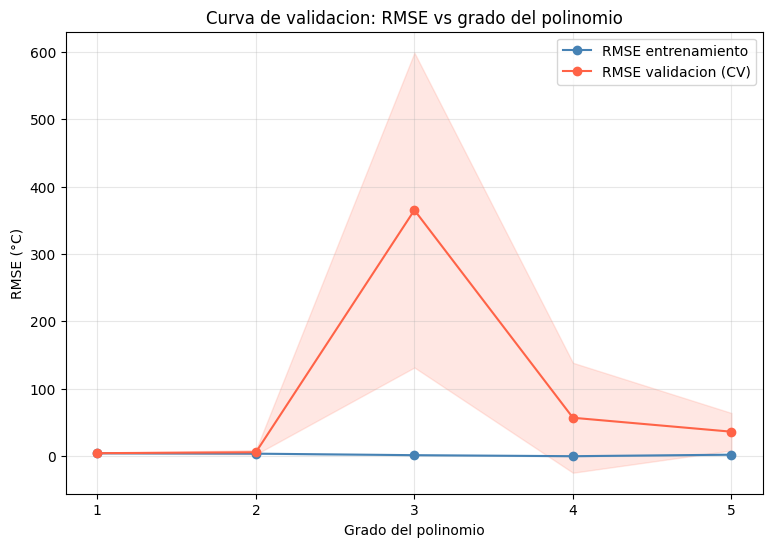

In [22]:
plt.figure(figsize=(9, 6))

plt.plot(grados, train_rmse_mean, 'o-', color='steelblue', label='RMSE entrenamiento')
plt.fill_between(grados, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std,
                  alpha=0.15, color='steelblue')

plt.plot(grados, val_rmse_mean, 'o-', color='tomato', label='RMSE validacion (CV)')
plt.fill_between(grados, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std,
                  alpha=0.15, color='tomato')

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE (°C)')
plt.title('Curva de validacion: RMSE vs grado del polinomio')
plt.xticks(grados)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**5.1 Diagnostico de la inestabilidad observada**

Aqui vemos que pico extremo en el RMSE de validacion en el grado 3 no corresponde a un sobreajuste gradual tipico sino a un problema de inestabilidad numerica, esto es interesante y conecta con lo que vimos en el laboratorio 1 del por que justo las variables cíclicas son las culpables por la transformacion que se hizo para arreglar la ciclicidad en el lab 1 se vuelve problemática al combinarla con polinomios de grado >= 2. Es por esto que se verifica esta hipotesis calculando el numero de condicion de la matriz de variables numericas tras aplicar `PolynomialFeatures` de grado 2 y la correlacion entre los terminos cuadraticos de las variables ciclicas creadas en el laboratorio 1.

In [23]:
from sklearn.preprocessing import PolynomialFeatures

X_num_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_train[num_cols]), 
    columns=num_cols
)
X_num_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_num_imputed), 
    columns=num_cols
)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_num_scaled)
feature_names = poly.get_feature_names_out(num_cols)

cond_number = np.linalg.cond(X_poly)
print(f"Número de condición de la matriz (grado 2): {cond_number:.2e}")

idx_sin2 = list(feature_names).index('dia_sin^2')
idx_cos2 = list(feature_names).index('dia_cos^2')
corr_sin2_cos2 = np.corrcoef(X_poly[:, idx_sin2], X_poly[:, idx_cos2])[0, 1]
print(f"\nCorrelación entre dia_sin² y dia_cos²: {corr_sin2_cos2:.4f}")

Número de condición de la matriz (grado 2): 6.33e+18

Correlación entre dia_sin² y dia_cos²: -0.8980


Se confirma que la curva de validacion no muestra un patron de sobreajuste gradual, sino un pico de 
inestabilidad extrema en grado 3 (RMSE promedio de más de 500°C, con folds individuales 
llegando a más de 1200°C). 
Nota: Al investigar la causa con ayuda de Claude para llegar a la raiz del problema, se calculo el numero de condicion de la matriz de diseño en grado 2, obteniendo un valor de 6.33.×10^18.

Segun esto la causa raiz es la colinealidad extrema introducida al elevar al cuadrado las variables cíclicas (`dia_sin`, `dia_cos`, `direccion_viento_sin`, `direccion_viento_cos`) creadas en el laboratorio 1 como mencione anteriormente, al satisfacer la identidad trigonometrica sin^2+cos^2= 1, sus versiones al cuadrado quedan casi perfectamente correlacionadas entre si lo que vuelve inestable la inversion de la matriz normal en `LinearRegression`.

Con esto se refuerza que el grado 1 es la mejor opcion ya que al introducir polinomios sobre variables ciclicas ya transformadas genera problemas numericos y no solo un trade-off sesgo-varianza convencional.

**5.2 Análisis del sobreajuste (sesgo-varianza y control de complejidad del modelo)**

Observando la curva de validación se identificaron dos secciones claramente diferenciadas:

**Grados 1-2 (zona de trade-off convencional):** El RMSE de entrenamiento y validación son similares y bajos (~5°C), sin brecha significativa entre ambos. Aquí el comportamiento del modelo sigue el patrón esperado del trade-off sesgo-varianza: en grado 1, el modelo tiene un sesgo ligeramente mayor al no capturar posibles no linealidades adicionales, pero una varianza mínima (predicciones estables entre folds). En grado 2 se introduce algo más de flexibilidad sin que la varianza se dispare todavía, aunque ya empieza a sembrarse la colinealidad que se manifestará plenamente en grado 3.

**Grados 3-5 (zona de inestabilidad numérica dominante):** El RMSE de entrenamiento permanece cercano a 0, mientras el RMSE de validación sube de forma abrupta (pico >500°C en grado 3, con folds individuales superando 1200°C y descenso parcial, pero aún inestable, en grados 4-5). La brecha extrema entre entrenamiento y validación es la prueba evidente de sobreajuste. Sin embargo, como se explicó en la sección anterior con el comportamiento de la gráfica y los datos calculados con ayuda de Claude, este comportamiento no corresponde a un sobreajuste gradual típico, sino a un problema de insteabilidad numérica causada por la colinealidad introducida al elevar al cuadradoo las variables cíclicas.

**Conclusión sobre el control de complejidad:** El punto de inflexión donde comienza a evidenciarse degradación de la capacidad de generalización es grado 3. El grado óptimo seleccionado por GridSearchCV (grado 1) resulta coherente con ambos análisis: no solo minimiza el error de validación cruzada según el RMSE, sino que evita por completo la inestabilidad numérica identificada.

Para el presente escenario, no bastó con mirar dónde sube el error de validación, también hubo que revisar las variables combinadas  y si tenían relaciones matemáticas exactas entre sí (como seno y coseno), pues eso genera inestabilidad numérica sin importar cuántos datos se tengan.

Este hallazgo anticipa un resultado relevante para la siguiente sección: la regularización debería permitir explorar grados más altos sin el colapso numérico observado aquí. Esta hipótesis se contrastará más adelante en la construcción de los modelos regularizados.

# 6.Construcción de modelos de regresión lineal regularizados
Se construirán pipelines que incorporen regularización L2 (Ridge) y L1 (Lasso), incluyendo el parámetro de penalización como hiperparámetro dentro de la búsqueda con GridSearchCV, así como las dos estrategias de escalamiento consideradas desde el pipelines sin regularización.

**6.1 Pipeline y búsqueda de hiperparámetros - Ridge (L2)**<br>
En esto punto construiremos el pipeline con `Ridge` como modelo de regresión, definiermos el `param_grid` para el parámetro de penalización (alfa) y las estrategias de escalamiento y ejecutaremos `GridSearchCV`. A partir de este, determinaremos los hiérparámetros que resultan en el mejor modelo y reportaremos sus métricas (RMSE, MAE, R²)

Las decisiones detras de la construcción del pipeline se mantendrán acordes a las presentadas en el laboratorio 1 y, por tanto, a las del punto anterior. Solo se harán los ajustes pertinentes sobre el modelo de regresión elegido.

In [24]:
# Transformación de características numéricas (sin términos polinomiales)
numeric_transformer_ridge = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Transformación de características categóricas (igual que en la sección 4)
categorical_transformer_ridge = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_ridge, num_cols),
        ('cat', categorical_transformer_ridge, cat_cols)
    ]
)

# Pipeline final con Ridge
pipeline_ridge = Pipeline(
    steps=[
        ('preprocessor', preprocessor_ridge),
        ('modelo', Ridge(random_state=42))
    ]
)

En el la definición del grid de hiperparámetros se incluyen tanto la penalización (alfa), como la estrategia de escalamiento. Para la definición inicial de los alfa de penalización incluimos un rango amplio de valores ([0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]). A medida que evaluemos su desempeño, este rango se acotará para encontrar el que dé mejor desempeño

In [41]:
# Primera versión del grid de búsqueda de hiperparámetros para Ridge
# param_grid_ridge = {
#     'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la primera versión, el mejor alfa encontrado fue 10.0, por lo que se ajusta el grid para explorar valores cercanos a este
# param_grid_ridge = {
#     'modelo__alpha': [1.0, 5.0, 10.0, 15.0, 20.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# En la segunda versión del grid, se encontró que el mejor alfa era 20.0, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
# param_grid_ridge = {
#     'modelo__alpha': [20.0, 25.0, 27.5, 30.0, 35.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# En la tercera versión del grid, se encontró que el mejor alfa era 35.0, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
param_grid_ridge = {
    'modelo__alpha': [32.5, 35.0, 37.5, 40.0],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

**Tras la tercera versión del grid encontramos que el mejor alfa era 35.0. Decidimos que este sería el valor final a usar para el modelo Ridge, y no se explorarán más valores de alfa.**

Se ejecuta `GridSearchCV` con los mismos parámteros de la sección 4 para mantener consistencia, salvo el scoring, pues consideraremos en RMSE para poder compararlo directamente entre el conjunto de entrenamiento y de prueba más adelante.

In [49]:
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Finalmente, se hace la evaluación del modelo con las distintas opciones de hiperparámetro definidas previamente y se reporta el de mejo desemepeño con sus métricas estadísitcas correspondientes

In [50]:
grid_ridge.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [32.5, 35.0, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [51]:
print(f'Mejor configuración (Ridge): {grid_ridge.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_ridge.best_score_):.4f} °C')

Mejor configuración (Ridge): {'modelo__alpha': 35.0, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE en validación cruzada: 4.5381 °C


In [52]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_ridge = grid_ridge.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_ridge.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba (Ridge) ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba (Ridge) ----
RMSE: 4.65
MAE: 3.54
R²: 0.72


**Resultados — Ridge:**

El mejor modelo encontrado por `GridSearchCV` usa `alpha=35.0` junto con `StandardScaler`. El RMSE en validación cruzada (RMSE ≈ 4.52°C) es consistente con el RMSE obtenido en el conjunto de test (4.65°C), lo que indica que el modelo generaliza adecuadamente sin señales 
de sobreajuste hacia los datos de entrenamiento.

En comparación con el modelo sin regularizar de la sección 4 (grado 1, sin penalización), Ridge con alpha=35 introduce una penalización moderada sobre la magnitud de los coeficientes. Esto es coherente con el diagnóstico de la sección 5: dado que la inestabilidad numérica identificada aparece principalmente al introducir términos polinomiales (grado ≥3) sobre las variables cíclicas, y este pipeline de Ridge no incluye `PolynomialFeatures`, no se esperaba una penalización extrema para corregir colinealidad.

Las métricas de test (RMSE: 4.65°C, MAE: 3.54°C, R²: 0.72) servirán como punto de comparación directo frente a Lasso (sección 6.2) y frente al modelo sin regularizar para la tabla comparativa de la sección 6.3.

**6.2 Pipeline y búsqueda de hiperparámetros - Lasso (L1)**<br>
En esto punto construiremos el pipeline con `Lasso` como modelo de regresión, definiermos el `param_grid` para el parámetro de penalización (alfa) y las estrategias de escalamiento y ejecutaremos `GridSearchCV`. A partir de este, determinaremos los hiérparámetros que resultan en el mejor modelo y reportaremos sus métricas (RMSE, MAE, R²). Adicionalmente, evaluaremos si alguna o algunas varaibles son llevadas a 0 y cuáles.

Nuevamente, las decisiones sobre el pipeline serán las mismas que en laboratorio 1 las secciones anteriores. Únicamente se harán los ajustes necesarios sobre el modelo de regresión elegido.

In [30]:
# Transformación de características numéricas (sin términos polinomiales, igual que en Ridge)
numeric_transformer_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Transformación de características categóricas (igual que en Ridge y en la sección 4)
categorical_transformer_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lasso, num_cols),
        ('cat', categorical_transformer_lasso, cat_cols)
    ]
)

# Pipeline final con Lasso
pipeline_lasso = Pipeline(
    steps=[
        ('preprocessor', preprocessor_lasso),
        ('modelo', Lasso(random_state=42, max_iter=10000))
    ]
)

Nuevamente, el grid de hiperparámetros contendrá las dos estrategias de escalamiento que hemos considerado todo el laboratorio el valor de penalización alfa.

Tal y como en la sección anterior, el rango de alfa empezará siendo amplio y lo iremos acotando a raíz del comportamiento que observemos para encontrar el mejor.

In [31]:
# Primer versión del grid de búsqueda de hiperparámetros para Lasso
# param_grid_lasso = {
#     'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la primera versión, el mejor alfa encontrado fue 0.1, por lo que se ajusta el grid para explorar valores cercanos a este
# param_grid_lasso = {
#     'modelo__alpha': [0.05, 0.1, 0.15, 0.2],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# Tras la segunda versión del grid, se encontró que el mejor alfa era 0.05, por lo que se ajusta nuevamente el grid para explorar valores cercanos a este
param_grid_lasso = {
    'modelo__alpha': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

**Tras la segunda versión del grid encontramos que el mejor alfa era 0.04. Decidimos que este sería el valor final a usar para el modelo Lasso y no se explorarán más valores de alfa.**

Ejecutaremos `GridSearchCV` con los mismos parámetros que en la sección anterior.

In [ ]:
grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Finalmente, se evalúa el modelo con las diferentes combinaciones de hiperparámetros para encontrar los mejores y se reportan el mejor modelo y las métricas estadísticas de aplicarlo al conjunto de prueba.

In [33]:
grid_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.01, 0.02, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [45]:
print(f'Mejor configuración (Lasso): {grid_lasso.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_lasso.best_score_):.2f} °C')

Mejor configuración (Lasso): {'modelo__alpha': 0.04, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE en validación cruzada: 4.52 °C


In [35]:
# Obtener el mejor modelo entrenado con la configuración óptima
mejor_lasso = grid_lasso.best_estimator_

# Reporte de las métricas estadísticas solicitadas (RMSE, MAE y R²)
y_test_pred = mejor_lasso.predict(X_test)
print('---- Métricas de evaluación en el conjunto de prueba (Lasso) ----')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

---- Métricas de evaluación en el conjunto de prueba (Lasso) ----
RMSE: 4.62
MAE: 3.52
R²: 0.72


A diferencia de Ridge, Lasso puede llevar a que algunas características tengan coeficientes exactamente cero, lo que implica que esas características no contribuyen al modelo final. Esto puede ser útil para la selección de características y para obtener modelos más interpretables.

A continuación, vamos a examinar los coeficientes del modelo Lasso para identificar qué características han sido seleccionadas y cuáles han sido eliminadas (coeficiente igual a cero).

In [36]:
preproc_fitted_lasso = mejor_lasso.named_steps["preprocessor"]
feature_names_lasso = preproc_fitted_lasso.get_feature_names_out()
coefs_lasso = mejor_lasso.named_steps["modelo"].coef_

coef_lasso_df = pd.DataFrame({
    "Característica": feature_names_lasso,
    "coef_lasso": coefs_lasso
})
coef_lasso_df["Característica"] = coef_lasso_df["Característica"].str.split("__").str[-1]
coef_lasso_df["coef_lasso"] = coef_lasso_df["coef_lasso"].round(3)
coef_lasso_df_sorted = coef_lasso_df.sort_values(
    "coef_lasso", key=abs, ascending=False
)
coef_lasso_df_sorted

,Característica,coef_lasso
16,dia_cos,-6.549
11,viento_norte,-1.739
15,dia_sin,-1.686
4,humedad_desv,1.585
17,direccion_viento_sin,0.822
14,anio,0.653
0,presion_media,0.556
8,rafaga_media,-0.425
25,mes_febrero,-0.393
20,estacion_anio_primavera,0.379


**Resultados — Lasso:**

El mejor modelo encontrado usa `alpha=0.04` junto con `StandardScaler`. El RMSE en validación cruzada (4.52°C) es consistente con el RMSE de test (4.62°C), confirmando buena generalización sin señales de sobreajuste.

Comparado con Ridge (RMSE test: 4.65°C, R²: 0.72), Lasso obtiene un desempeño prácticamente idéntico (RMSE test: 4.62°C, R²: 0.72) — la diferencia de 0.03°C en RMSE no es extremadamente significativo en términos prácticos. Esto sugiere que, para este problema, el valor principal de Lasso no está en mejorar la capacidad predictiva sobre Ridge, sino en su capacidad de selección automática de variables: de las 40 columnas generadas tras el preprocesamiento, Lasso llevó a exactamente cero 19 de ellas (principalmente variables 
dummy de mes y sector_viento con escasa señal), conservando un modelo bastante más interpretable sin sacrificar desempeño.

In [46]:
# Identificación de variables eliminadas (coeficiente = 0) vs. conservadas
coef_lasso_df['seleccionada'] = coef_lasso_df['coef_lasso'] != 0

n_total = len(coef_lasso_df)
n_eliminadas = (~coef_lasso_df['seleccionada']).sum()
n_conservadas = coef_lasso_df['seleccionada'].sum()

print(f"Total de características tras preprocesamiento: {n_total}")
print(f"Características eliminadas (coef = 0): {n_eliminadas} ({n_eliminadas/n_total:.1%})")
print(f"Características conservadas (coef ≠ 0): {n_conservadas} ({n_conservadas/n_total:.1%})")

print("\nCaracterísticas eliminadas por Lasso:")
print(coef_lasso_df.loc[~coef_lasso_df['seleccionada'], 'Característica'].tolist())

Total de características tras preprocesamiento: 40
Características eliminadas (coef = 0): 19 (47.5%)
Características conservadas (coef ≠ 0): 21 (52.5%)

Características eliminadas por Lasso:
['viento_min', 'viento_este', 'estacion_anio_otoño', 'estacion_anio_verano', 'mes_agosto', 'mes_diciembre', 'mes_julio', 'mes_junio', 'mes_marzo', 'mes_mayo', 'mes_noviembre', 'mes_octubre', 'mes_septiembre', 'sector_viento_n', 'sector_viento_ne', 'sector_viento_no', 'sector_viento_o', 'sector_viento_se', 'sector_viento_so']


Con alpha=0.04, Lasso eliminó 19 de las 40 características disponibles tras el preprocesamiento (47.5%), conservando un modelo considerablemente más compacto sin pérdida relevante de desempeño respecto a Ridge (RMSE test: 4.62°C vs. 4.65°C).

Las variables eliminadas siguen un patrón claro por categoría:

1. sector_viento: de las 7 columnas dummy generadas (tras eliminar la categoría base con drop='first'), solo sector_viento_s conserva un coeficiente distinto de cero (0.207). Las 6 restantes (n, ne, no, o, se, so) fueron eliminadas. Esto sugiere que, controlando por las demás variables meteorológicas ya incluidas (como direccion_viento_sin/cos, que capturan la dirección de forma continua), el sector categórico del viento aporta poca información adicional, salvo posiblemente para viento del sur.
2. mes: de las 11 columnas dummy (tras drop='first'), solo mes_enero y mes_febrero sobreviven, ambas con coeficiente negativo. Esto es coherente con el hecho de que ya se incluyen dia_sin/dia_cos (que capturan la estacionalidad de forma continua y cíclica). Es decir, el mes como variable categórica aporta señal adicional principalmente en los meses de temperaturas más extremas del año, mientras que el resto queda redundante frente a la interpretación cíclica.
3. estacion_anio: de las 3 columnas dummy, solo estacion_anio_primavera se conserva (0.379); otoño y verano fueron eliminadas, reforzando la misma idea de redundancia con las variables cíclicas.
4. Numéricas (viento_min, viento_este): eliminadas, sugiriendo baja correlación con la variable objetivo una vez consideradas las demás variables de viento (viento_norte, viento_media, viento_desv).

Este resultado muestra que gran parte de las variables categóricas relacionadas con temporalidad (mes, estacion_anio) resultan redundantes frente a la interpretación cíclica seno/coseno construida en el Laboratorio 1. Es decir, Lasso está detectando automáticamente una relación que ya sabíamos por construcción: ambas fuentes de información (variables cíclicas continuas y variables categóricas de calendario) capturan, el mismo fenómeno de estacionalidad y el modelo prioriza la representación continua.

**6.3 Tabla comparativa** 

Con los tres modelos ajustados (regresión lineal simple de la sección 4, Ridge y Lasso), se construye una tabla comparativa que integra no solo el desempeño promedio en validación cruzada, sino también su variabilidad (desviación estándar), junto con las métricas finales sobre el conjunto de test. Esto permite evaluar el efecto de la regularización tanto en la capacidad de generalización como en la estabilidad del modelo. 

In [53]:
def obtener_metricas_cv(grid_search, nombre_modelo):
    """Extrae media y std del mejor resultado de un GridSearchCV (en RMSE, °C)."""
    idx_mejor = grid_search.best_index_
    cv_results = grid_search.cv_results_
    
    rmse_mean = np.sqrt(-cv_results['mean_test_score'][idx_mejor])
    mse_std = cv_results['std_test_score'][idx_mejor]
    rmse_std = mse_std / (2 * rmse_mean) 
    
    return {
        'Modelo': nombre_modelo,
        'Mejores hiperparámetros': grid_search.best_params_,
        'RMSE CV (media)': round(rmse_mean, 4),
        'RMSE CV (std)': round(rmse_std, 4)
    }

def obtener_metricas_test(grid_search, nombre_modelo, X_test, y_test):
    """Calcula RMSE, MAE y R² del mejor modelo sobre el conjunto de test."""
    y_pred = grid_search.best_estimator_.predict(X_test)
    return {
        'Modelo': nombre_modelo,
        'RMSE test': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE test': round(mean_absolute_error(y_test, y_pred), 4),
        'R² test': round(r2_score(y_test, y_pred), 4)
    }

# Recolección de resultados de los tres modelos
modelos = [
    (grid, 'Sin regularización (grado 1)'),
    (grid_ridge, 'Ridge (L2)'),
    (grid_lasso, 'Lasso (L1)')
]

resumen_cv = pd.DataFrame([obtener_metricas_cv(g, n) for g, n in modelos])
resumen_test = pd.DataFrame([obtener_metricas_test(g, n, X_test, y_test) for g, n in modelos])

tabla_comparativa = resumen_cv.merge(resumen_test, on='Modelo')
tabla_comparativa = tabla_comparativa[
    ['Modelo', 'RMSE CV (media)', 'RMSE CV (std)', 'RMSE test', 'MAE test', 'R² test', 'Mejores hiperparámetros']
]
tabla_comparativa

,Modelo,RMSE CV (media),RMSE CV (std),RMSE test,MAE test,R² test,Mejores hiperparámetros
0,Sin regularización (grado 1),4.5437,0.3388,4.6752,3.5669,0.7133,"{'preprocessor__num__polynomial__degree': 1, '..."
1,Ridge (L2),4.5381,0.3473,4.6460,3.5368,0.7169,"{'modelo__alpha': 35.0, 'preprocessor__num__sc..."
2,Lasso (L1),4.5247,0.3532,4.6246,3.5240,0.7195,"{'modelo__alpha': 0.04, 'preprocessor__num__sc..."


**Conclusión:** Las diferencias entre los tres modelos son pequeñas en términos absolutos (todas las métricas están dentro de un rango de ~0.05°C de RMSE y ~0.006 de R²), lo que sugiere que, en este pipeline sin componente polinomial, la regularización aporta una mejora modesta pero consistente en desempeño. La elección entre Ridge y Lasso en este punto probablemente deba apoyarse más en criterios de interpretabilidad (Lasso ofrece selección automática de variables).

**6.4 Análisis de la magnitud de los coeficientes**

Esta sección compara directamente los coeficientes de los tres modelos para visualizar el efecto de la regularización sobre su magnitud.

In [60]:
# Extracción de coeficientes de los tres modelos
feature_names_lineal = grid.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names_ridge = grid_ridge.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names_lasso = grid_lasso.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

coef_lineal = grid.best_estimator_.named_steps['modelo'].coef_
coef_ridge = grid_ridge.best_estimator_.named_steps['modelo'].coef_
coef_lasso_vals = grid_lasso.best_estimator_.named_steps['modelo'].coef_

comparacion_coefs = pd.DataFrame({
    'Característica': feature_names_ridge, 
    'coef_sin_regularizar': coef_lineal,
    'coef_ridge': coef_ridge,
    'coef_lasso': coef_lasso_vals
})

comparacion_coefs = comparacion_coefs.sort_values('coef_sin_regularizar', ascending=True)

comparacion_coefs.head(15)

,Característica,coef_sin_regularizar,coef_ridge,coef_lasso
16,num__dia_cos,-6.549721,-6.369220,-6.548575
35,cat__sector_viento_no,-3.515936,-0.641236,-0.000000
36,cat__sector_viento_o,-2.689072,-0.326683,-0.000000
39,cat__sector_viento_so,-2.232159,-0.211212,-0.000000
33,cat__sector_viento_n,-2.168580,-0.346070,-0.000000
38,cat__sector_viento_se,-2.079293,-0.593859,-0.000000
15,num__dia_sin,-1.804922,-1.713446,-1.685664
11,num__viento_norte,-1.692784,-1.533850,-1.739135
25,cat__mes_febrero,-1.588770,-0.855993,-0.393275
37,cat__sector_viento_s,-1.330048,0.273025,0.206503


In [61]:
# Resumen estadístico de la magnitud de los coeficientes por modelo
resumen_magnitud = pd.DataFrame({
    'Modelo': ['Sin regularización', 'Ridge (L2)', 'Lasso (L1)'],
    'Suma |coef|': [
        comparacion_coefs['coef_sin_regularizar'].abs().sum(),
        comparacion_coefs['coef_ridge'].abs().sum(),
        comparacion_coefs['coef_lasso'].abs().sum()
    ],
    'Coef. máximo (abs)': [
        comparacion_coefs['coef_sin_regularizar'].abs().max(),
        comparacion_coefs['coef_ridge'].abs().max(),
        comparacion_coefs['coef_lasso'].abs().max()
    ],
    'Desv. estándar de coefs': [
        comparacion_coefs['coef_sin_regularizar'].std(),
        comparacion_coefs['coef_ridge'].std(),
        comparacion_coefs['coef_lasso'].std()
    ],
    'N° coefs = 0': [
        (comparacion_coefs['coef_sin_regularizar'] == 0).sum(),
        (comparacion_coefs['coef_ridge'] == 0).sum(),
        (comparacion_coefs['coef_lasso'] == 0).sum()
    ]
})
resumen_magnitud

,Modelo,Suma |coef|,Coef. máximo (abs),Desv. estándar de coefs,N° coefs = 0
0,Sin regularización,41.057775,6.549721,1.378834,0
1,Ridge (L2),21.959593,6.369220,1.143052,0
2,Lasso (L1),15.992205,6.548575,1.155130,19


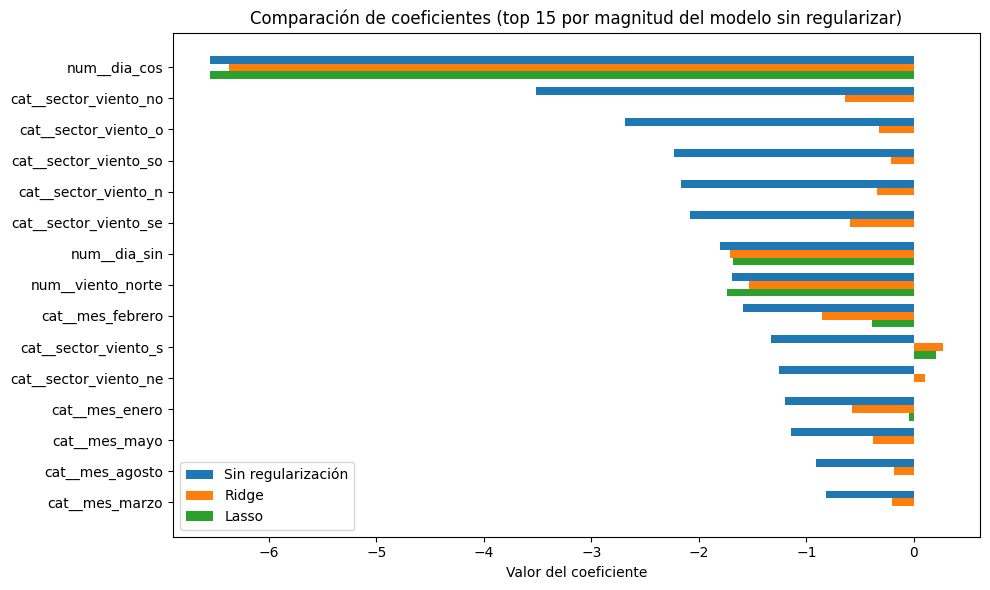

In [62]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 15
top_features = comparacion_coefs.head(top_n)['Característica']

x = np.arange(len(top_features))
width = 0.25

ax.barh(x - width, comparacion_coefs.head(top_n)['coef_sin_regularizar'], 
        height=width, label='Sin regularización')
ax.barh(x, comparacion_coefs.head(top_n)['coef_ridge'], 
        height=width, label='Ridge')
ax.barh(x + width, comparacion_coefs.head(top_n)['coef_lasso'], 
        height=width, label='Lasso')

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Valor del coeficiente')
ax.set_title(f'Comparación de coeficientes (top {top_n} por magnitud del modelo sin regularizar)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

La regularización, incluso en ausencia del problema de colinealidad severa evidenciado en la sección 5 (pues solo aparecía con grado >= 3), sigue aportando valor real en el pipeline lineal: corrige coeficientes inflados en variables categóricas de baja frecuencia (sector_viento), reduce la magnitud general de los coeficientes sin sacrificar la señal de las variables genuinamente relevantes (dia_cos, dia_sin, humedad_desv), y en el caso de Lasso, simplifica el modelo mediante selección automática. Esto refuerza la conclusión de la sección 6.3: aunque las diferencias en RMSE/R² entre los tres modelos son pequeñas, los modelos regularizados (particularmente Lasso) ofrecen un modelo más interpretables.

# 7. Construcción de un modelo de regresión polinomial regularizado

Se implementará un pipeline que combine la generación de características polinomiales con un modelo regularizado. En nuestro caso hemos elegido Lasso, pues no solo presentó una mejora marginal en las métricas estadísticas calculadas en la sección anterior, sino que también tiene la capacidad de simplificar el modelo llevando variables a cero. Consideramos que esto es especialmente relevante en un modelo polinomial, dado que una de sus mayores desventajas es el costo computacional asociado al cálculo de las variables adicionales generadas en función del grado considerado.

La búsqueda de hiperparámetros considerará las siguientes características:
1. Grado del polinomio
2. Parámetro de penalización
3. Estrategia de escalamiento (entre las mismas dos consideradas a lo largo del laboratorio)

Finalmente, se reportarán las métricas de RMSE, MAE y R² obtenidas para el mejor modelo.

**7.1 Creación del pipeline con características polinomiales y regularización**

El pipeline aquí construido se rige por las mismas decisiones tomadas y justificadas previamente: imputación por mediana/moda, escalamiento antes de generar las características polinomiales, `drop='first'` en las variables categóricas, e `include_bias=False` en `PolynomialFeatures` para evitar redundancia con el intercepto del modelo. Los únicos cambios corresponden a los propios del enunciado de esta sección: la incorporación de `PolynomialFeatures` sobre las variables numéricas y el uso de `Lasso` como modelo final, con su respectivo parámetro de penalización dentro de la búsqueda.

In [63]:
# Transformación de características numéricas (con términos polinomiales)
numeric_transformer_poly_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ]
)

# Transformación de características categóricas (igual que en la sección 4)
categorical_transformer_poly_lasso = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]
)

# Preprocesamiento
preprocessor_poly_lasso = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_lasso, num_cols),
        ('cat', categorical_transformer_poly_lasso, cat_cols)
    ]
)

# Pipeline final con Lasso y polinomios
pipeline_poly_lasso = Pipeline(
    steps=[
        ('preprocessor', preprocessor_poly_lasso),
        ('modelo', Lasso(random_state=42, max_iter=10000))
    ]
)

Se define el grid de hiperparámteros para contemplar las tres dimensiones mencionadas al inicio de esta sección. Se recuerda que el proceso para encontrar los hiperparámetros que resulten en el mejor modelo es iterativo.

In [ ]:
# Primer grid de búsqueda de hiperparámetros para Lasso con polinomios
# param_grid_poly_lasso = {
#     'preprocessor__num__polynomial__degree': [1, 2, 3, 4],
#     'modelo__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
#     'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
# }

# En la primera versión del grid, se encontró que el mejor grado era 4 y el mejor alfa era 0.01, por lo que se ajusta nuevamente el grid para explorar valores cercanos a estos
param_grid_poly_lasso = {
    'preprocessor__num__polynomial__degree': [3, 4, 5],
    'modelo__alpha': [0.0055, 0.01, 0.05],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
}

Se ejecuta `GridSearchCV` con los mismos parámetros que en el resto de escenarios evaluados previamente para mantener consistencia en los resultados

In [65]:
grid_poly_lasso = GridSearchCV(
    estimator=pipeline_poly_lasso,
    param_grid=param_grid_poly_lasso,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

Evaluar el modelo con las distintas combinaciones para encontrar el mejor de todos:

In [66]:
grid_poly_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...], 'preprocessor__num__polynomial__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versioncha

In [67]:
print(f'Mejor configuración (Polinomial + Lasso): {grid_poly_lasso.best_params_}')
print(f'Mejor RMSE en validación cruzada: {np.sqrt(-grid_poly_lasso.best_score_):.4f} °C')

Mejor configuración (Polinomial + Lasso): {'modelo__alpha': 0.01, 'preprocessor__num__polynomial__degree': 4, 'preprocessor__num__scaler': MinMaxScaler()}
Mejor RMSE en validación cruzada: 4.2059 °C
